<a href="https://colab.research.google.com/github/UghurKhalilov/Airlines-flights/blob/main/Airlines_flights_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install pandas

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
ssh-keygen -t ed25519 -C "ughurkhalilov85@gmail.com"

SyntaxError: invalid syntax (3861357382.py, line 1)

In [4]:
import pandas as pd

In [5]:
from google.colab import files
uploaded = files.upload()

Saving airlines_flights_data.csv to airlines_flights_data.csv


In [6]:
airlines_data=pd.read_csv("/content/airlines_flights_data.csv")

In [7]:
airlines_data.head()

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [ ]:
airlines_data.tail()

In [8]:
### Umumi airlines_flight sayi

flight_count = airlines_data['airline'].count()
print(f"Flight count: {flight_count}")

Flight count: 300153


In [9]:
### Airline gore ortalama gedib catma vaxti
airlines_data.groupby("airline").agg({"duration": "mean"})

,duration
airline,
AirAsia,8.941714
Air_India,15.504235
GO_FIRST,8.755380
Indigo,5.795197
SpiceJet,12.579767
Vistara,13.326634


In [ ]:
airlines_data.shape

In [10]:
airlines_data["price"].max()

123071

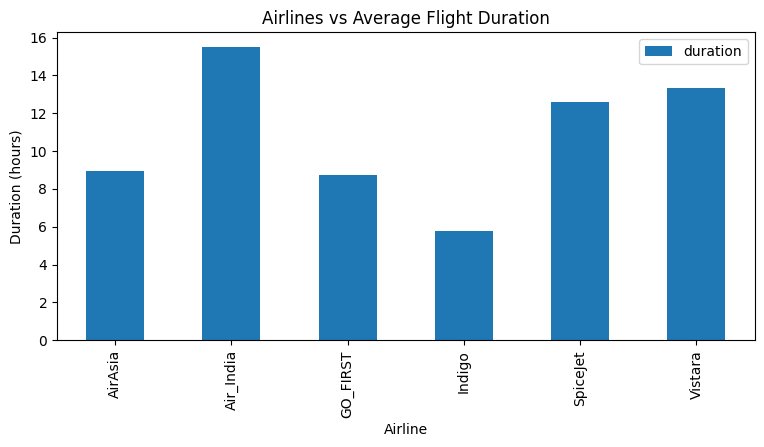

In [14]:
import numpy as np
import matplotlib.pyplot as plt
avg_duration=airlines_data.groupby("airline").agg({"duration": 'mean'})
avg_duration.plot(kind="bar",figsize=(9,4))
plt.title("Airlines vs Average Flight Duration")
plt.xlabel("Airline")
plt.ylabel("Duration (hours)")
plt.show()

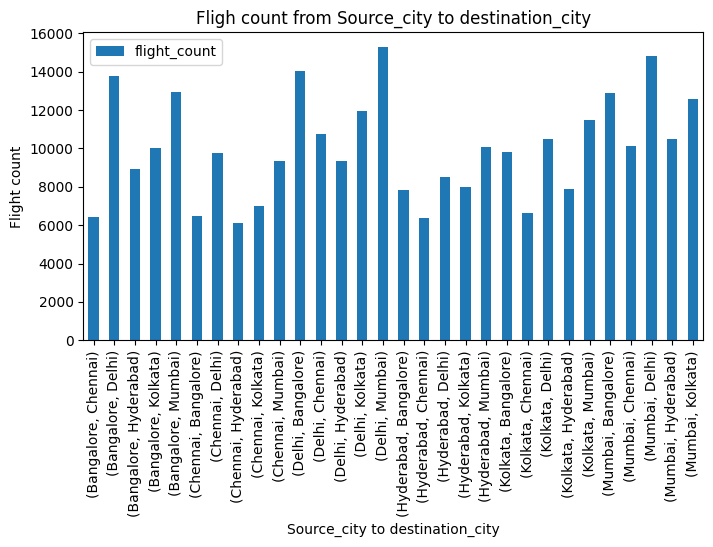

In [16]:
flight_count=airlines_data.groupby(["source_city", "destination_city"]).agg(flight_count=('flight', 'count'))
flight_count.plot(kind="bar",figsize=(8,4))
plt.title("Fligh count from Source_city to destination_city")
plt.xlabel("Source_city to destination_city")
plt.ylabel("Flight count")
plt.show()

In [ ]:
airlines_data.groupby("airline").agg({"price": mean}).sort_values(by='price', ascending=True).reset_index()

In [ ]:
airlines_data.groupby("duration").agg({"price": mean})


In [ ]:
airlines_data.groupby(["source_city", "destination_city"]).agg({"price": 'mean'}).sort_values(by='price',ascending=True).reset_index()

In [ ]:
airlines_data[airlines_data["days_left"].isin([1,2])].groupby("days_left").agg({"price":'mean'}).reset_index()

In [23]:
airlines_data.head()

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,leftday_groups
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953,0-10
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953,0-10
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956,0-10
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955,0-10
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955,0-10


In [22]:
airlines_data.groupby('class')['price'].mean()

,price
class,
Business,52540.081124
Economy,6572.342383


In [21]:
airlines_data.groupby(["airline","class"]).agg({"duration":"mean"}).reset_index()

,airline,class,duration
0,AirAsia,Economy,8.941714
1,Air_India,Business,14.634917
2,Air_India,Economy,16.100119
3,GO_FIRST,Economy,8.755380
4,Indigo,Economy,5.795197
5,SpiceJet,Economy,12.579767
6,Vistara,Business,13.198963
7,Vistara,Economy,13.441626


In [20]:
airlines_data.groupby("stops").agg({'price':"mean"}).reset_index()

,stops,price
0,one,22900.992482
1,two_or_more,14113.450775
2,zero,9375.938535


In [19]:
airlines_data["leftday_groups"]=pd.cut(airlines_data["days_left"],bins=[0,10,20,30,40,50],labels=["0-10","11-20","21-30","31-40","41-50"])

In [24]:
airlines_data[["leftday_groups",'days_left']].head()

,leftday_groups,days_left
0,0-10,1
1,0-10,1
2,0-10,1
3,0-10,1
4,0-10,1


/tmp/ipykernel_1444/3965113450.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  changing_prices=airlines_data.groupby("leftday_groups")["price"].mean().reset_index()


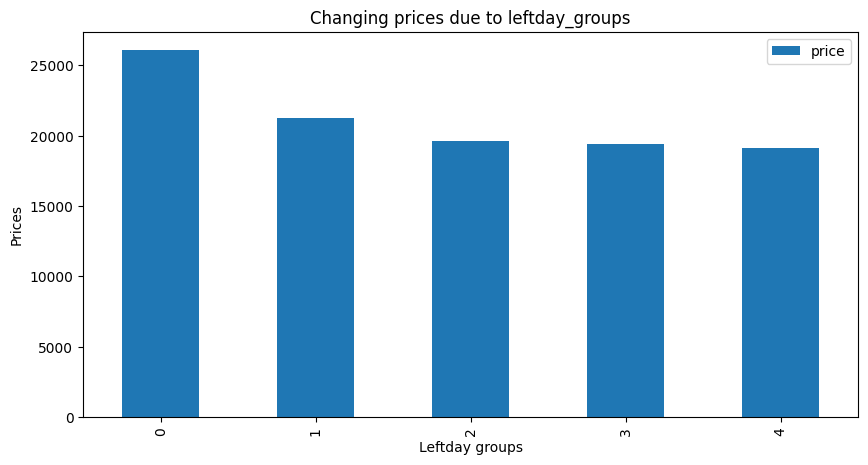

In [25]:
changing_prices=airlines_data.groupby("leftday_groups")["price"].mean().reset_index()
changing_prices.plot(kind="bar",figsize=(10,5))
plt.title("Changing prices due to leftday_groups")
plt.xlabel("Leftday groups")
plt.ylabel("Prices")
plt.show()

In [29]:
airlines_data["source_city"].value_counts()

,count
source_city,
Delhi,61343
Mumbai,60896
Bangalore,52061
Kolkata,46347
Hyderabad,40806
Chennai,38700


In [28]:
airlines_data.groupby("source_city").agg({"flight":'count',
                                           "price":'mean' }).sort_values(by="flight",ascending=True)

,flight,price
source_city,,
Chennai,38700,21995.339871
Hyderabad,40806,20155.623879
Kolkata,46347,21746.235679
Bangalore,52061,21469.460575
Mumbai,60896,21483.818839
Delhi,61343,18951.326639


In [27]:
airlines_data.groupby("class").agg({"flight":'count',
                                    "price": "mean"  })

,flight,price
class,,
Business,93487,52540.081124
Economy,206666,6572.342383


In [26]:
airlines_data.groupby(["source_city","airline"]).agg(
    min_price=('price', 'min'),
    max_price=('price', 'max')
).reset_index()

,source_city,airline,min_price,max_price
0,Bangalore,AirAsia,1603,25993
1,Bangalore,Air_India,1966,88030
2,Bangalore,GO_FIRST,1714,30284
3,Bangalore,Indigo,1604,29213
4,Bangalore,SpiceJet,1606,34158
5,Bangalore,Vistara,1714,111883
6,Chennai,AirAsia,1105,21364
7,Chennai,Air_India,1526,89257
8,Chennai,GO_FIRST,1105,15289
9,Chennai,Indigo,1105,24047
